In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.pfr as pfr
import src.cstr as cstr
from scipy.integrate import trapezoid, quad

# Apendice (Sesión 03)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# Ejemplos de implementación

In [102]:
k = 0.1     # Reaction rate constant (1/min)
V_total = 100.0  # Total volume of the reactors (L)
Q = 10.0        # Volumetric flow rate (L/min)
C_in = 1.0    # Initial concentration of A (mol/L)
order = 1.0

## 3.1 Conversión CSTR

### 3.1.1 CSTR en serie

Efecto del número de reactores CSTR en serie sobre la conversión total, para un volumen total de reactor(es) fijo:

- Para un volumen total fijo, el número de reactores CSTR es directamente proporcional a la conversión.

- Cuando el número de reactores tiende a infinito, la conversión tiende a aquella que se puede lograr en un PFR.

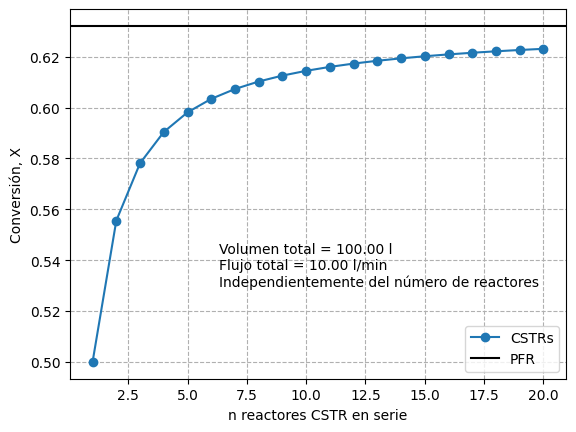

In [103]:
# Parameters
num_reactors = 20

ind_reactors = np.arange(1, num_reactors + 1)
X_reactors = []

for ind in ind_reactors:
    cstr_ind, cstr_X = cstr.cstrInSeriesX(
        ind,
        k,
        C_in,
        Q,
        V_total,
        order
    )
    X_reactors.append(cstr_X[-1])
X_reactors = np.array(X_reactors)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    1,
    k,
    C_in,
    Q,
    V_total,
    order
)

fig, ax = plt.subplots()
ax.plot(ind_reactors, X_reactors, marker='o', label='CSTRs')
ax.axhline(pfr_X[-1], color='k', label="PFR")
ax.set(
    xlabel="n reactores CSTR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
ax.legend()
plt.show()

### 3.1.2 CSTR en paralelo

Efecto del número de reactores CSTR en paralelo sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión es la misma independientemente del número de reactores.

- Esto es porque al dividir el volumen y el flujo totales en $n$ reactores iguales con flujos iguales, el tiempo espacial será el mismo para todos los reactores.

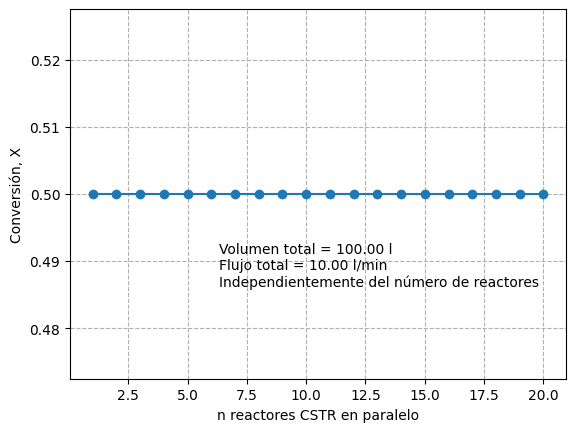

In [104]:
num_reactors = 20

cstr_ind, cstr_X = cstr.cstrInParallelX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()
ax.plot(cstr_ind, cstr_X, marker='o')
ax.set(
    xlabel="n reactores CSTR en paralelo",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()

## 3.2 Conversión PFR

### 3.2.1 PFR en serie

Efecto del número de reactores PFR en serie sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión lograda en $n$ reactores PFR es la misma que la lograda en un solo reactor PFR del mismo volumen.


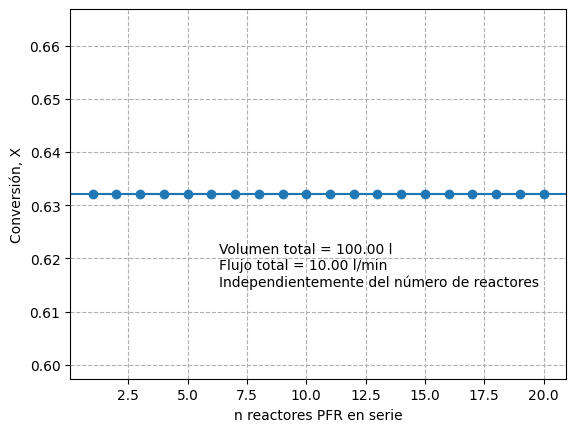

In [105]:
# Parameters
num_reactors = 20

ind_reactors = np.arange(1, num_reactors + 1)
X_reactors = []

for ind in ind_reactors:
    pfr_ind, pfr_X = pfr.pfrInSeriesX(
        num_reactors,
        k,
        C_in,
        Q,
        V_total,
        order
    )
    X_reactors.append(pfr_X[-1])
X_reactors = np.array(X_reactors)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    1,
    k,
    C_in,
    Q,
    V_total,
    order
)

fig, ax = plt.subplots()
ax.plot(ind_reactors, X_reactors, marker='o')
ax.axhline(pfr_X[-1])
ax.set(
    xlabel="n reactores PFR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()

### 3.2.2 PFR en paralelo

Efecto del número de reactores PFR en paralelo sobre la conversión total, para un volumen total de reactor(es) fijo:

- La conversión lograda en $n$ reactores PFR es la misma que la lograda en un solo reactor PFR del mismo volumen.

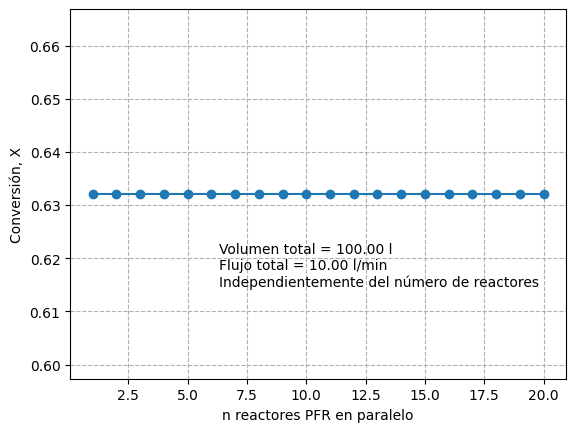

In [106]:
# Parameters
num_reactors = 20

pfr_ind, pfr_X = pfr.pfrInParallelX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()
ax.plot(pfr_ind, pfr_X, marker='o')
ax.set(
    xlabel="n reactores PFR en paralelo",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = "Independientemente del número de reactores"
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
plt.show()


## 3.3 Arreglos diversos

### 3.3.1 Arreglo de varios CSTR o de varios PFR en series

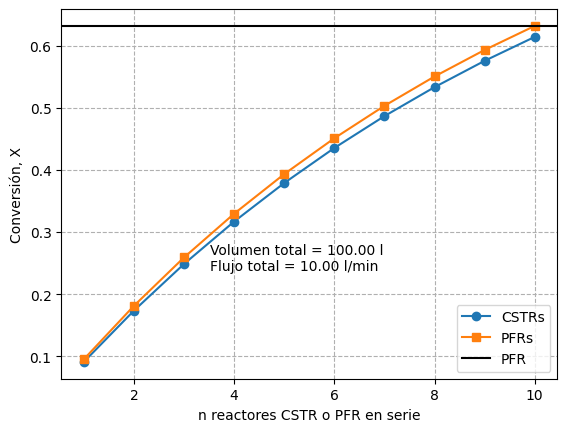

In [107]:
# Parameters
num_reactors = 10

cstr_ind, cstr_X = cstr.cstrInSeriesX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)

pfr_ind, pfr_X = pfr.pfrInSeriesX(
    num_reactors,
    k,
    C_in,
    Q,
    V_total,
    order
)


fig, ax = plt.subplots()

ax.plot(cstr_ind[1:], cstr_X[1:], marker='o', label='CSTRs')
ax.plot(pfr_ind[1:], pfr_X[1:], marker='s', label='PFRs')
ax.axhline(pfr_X[-1], c='k', label='PFR')
ax.set(
    xlabel="n reactores CSTR o PFR en serie",
    ylabel="Conversión, X",
)
n1 = f"Volumen total = {V_total:.2f} l \n"
n2 = f"Flujo total = {Q:.2f} l/min \n"
n3 = ""
ax.annotate("".join([n1, n2, n3]), xy=(0.3, 0.25), xycoords='axes fraction')
ax.grid(ls='--')
ax.legend()
plt.show()

### 3.3.2 Arreglo CSTR/PFR en series (combinados)

In [108]:
def rA_O1(X, k, C0, n):
    return -k*(C0)**n * (1-X)**n

def inv_rA_01(X, k, C0, n):
    return 1/(k*(C0)**n * (1-X)**n)

In [109]:
# Entrada
k = 1   # constante de reacción
c0 = 1  # concentración inicial
n = 1   # orden de reacción

X = np.linspace(0, 0.8, 801)
rA = rA_O1(X, k, c0, n)
# Creación de DataFrame con datos de interés
df = pd.DataFrame({"X": X, '-rA': -rA})
df['1/-rA'] = 1/df['-rA'] # [(mol-1.m3).s]
display(df)

,X,-rA,1/-rA
0,0.000,1.000,1.000000
1,0.001,0.999,1.001001
2,0.002,0.998,1.002004
3,0.003,0.997,1.003009
4,0.004,0.996,1.004016
...,...,...,...
796,0.796,0.204,4.901961
797,0.797,0.203,4.926108
798,0.798,0.202,4.950495
799,0.799,0.201,4.975124


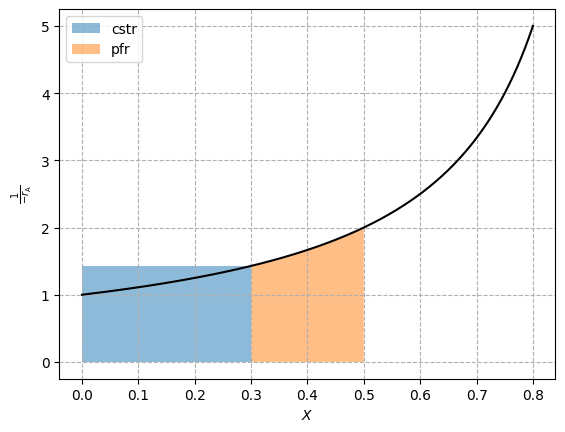

    n    Volumen    Tipo
-----------------------
    1 |   4.2857 | cstr
    2 |   3.3647 | pfr
Volumen total: 7.6504


In [119]:
### Indicar tipos de reactores, conversiones, y datos a tratar (x, y) ##########
reactors = ['cstr', 'pfr']
targets = np.array([0.3, 0.5])
x, y = df['X'].to_numpy(), 1/df['-rA'].to_numpy()

### Graficar datos #############################################################
fig, ax = plt.subplots()
areas = np.zeros_like(targets)
ax.plot(x, y, color='k')
for ii, reactor in enumerate(reactors):
    # encontrar indices cercanos a conversión inicial
    if ii==0:
        x0 = 0.0
        ind0 = 0
    else:
        x0 = targets[ii-1]
        diffs0 = np.abs(x0 - x)
        ind0 = diffs0.argmin()
    # encontrar indices cercanos a conversión final
    x1 = targets[ii]
    diffs1 = np.abs(x1 - x)
    ind1 = diffs1.argmin()
    # calcular y graficar el área que corresponde a cada reactor
    if reactor.lower() == 'cstr':
        areas[ii] = (x[ind1] - x[ind0]) * y[ind1]
        ax.fill_between(x[ind0:ind1+1], y[ind1]*np.ones_like(x[ind0:ind1+1]), label=f'{reactor}', alpha=0.5)
    else:
        #areas[ii] = trapezoid(y[ind0:ind1+1], x[ind0:ind1+1])
        areas[ii] = quad(inv_rA_01, x0, x1, args=(k, c0, n))[0]
        ax.fill_between(x[ind0:ind1+1], y[ind0:ind1+1], label=f'{reactor}', alpha=0.5)
# formato gráfico
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.legend()
ax.grid(ls='--')
plt.show()

### Tratamiento de datos #######################################################
# Establecer flujo molar (regimen estacionario), calcular volumenes de reactores
F0 = 10.0
Vols = F0 * areas
# imprimir resultados brutos
print("    n    Volumen    Tipo")
print("-----------------------")
for ii, reactor in enumerate(reactors):
    print(f"{ii+1:5} | {Vols[ii]:8.4f} | {reactor}")
print(f"Volumen total: {np.sum(Vols):.4f}")

## 3.4 Reactores con recirculación

In [111]:
# Entrada
k = 1   # constante de reacción
c0 = 1  # concentración inicial
n = 1   # orden de reacción

X = np.linspace(0, 0.8, 801)
rA = rA_O1(X, k, c0, n)
# Creación de DataFrame con datos de interés
df = pd.DataFrame({"X": X, '-rA': -rA})
df['1/-rA'] = 1/df['-rA'] # [(mol-1.m3).s]
display(df)

,X,-rA,1/-rA
0,0.000,1.000,1.000000
1,0.001,0.999,1.001001
2,0.002,0.998,1.002004
3,0.003,0.997,1.003009
4,0.004,0.996,1.004016
...,...,...,...
796,0.796,0.204,4.901961
797,0.797,0.203,4.926108
798,0.798,0.202,4.950495
799,0.799,0.201,4.975124


### 3.4.1 Análisis gráfico

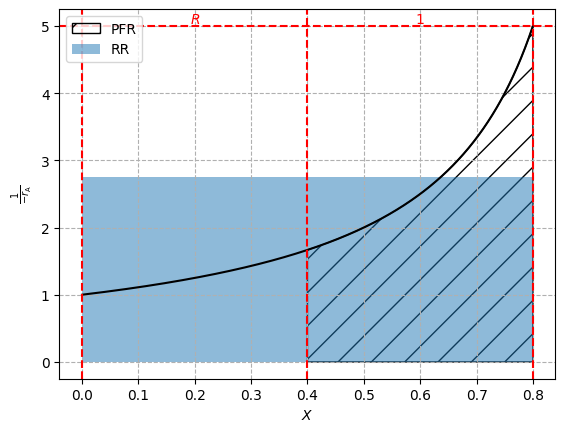

    n    Volumen    Tipo
-----------------------
   1   |  21.9722 | RR


In [120]:
### Indicar tipos de reactores, conversiones, y datos a tratar (x, y) ##########
R = 1
x1 = 0.8
x, y = df['X'].to_numpy(), 1/df['-rA'].to_numpy()

### Graficar datos #############################################################
fig, ax = plt.subplots()
ax.plot(x, y, color='k')
# encontrar indices cercanos a conversión inicial
x0 = R/(R+1) * x1
diffs0 = np.abs(x0 - x)
ind0 = diffs0.argmin()
# encontrar indices cercanos a conversión final
diffs1 = np.abs(x1 - x)
ind1 = diffs1.argmin()
# calcular y graficar el área que corresponde a cada reactor
#area = (R+1) * trapezoid(y[ind0:ind1+1], x[ind0:ind1+1])
area = ((R+1) * quad(inv_rA_01, x0, x1, args=(k, c0, n))[0])
ax.fill_between(x[ind0:ind1+1], y[ind0:ind1+1], hatch='/', facecolor='None', edgecolor='k', label='PFR')
# calcular la altura promedio
height = area / x1
ax.fill_between([0, x1], [height, height], alpha=0.5, label='RR')
# Indicativo de R + 1...
ax.axvline(0, c='r', ls='--')
ax.annotate(f"$R$", xy=(x0/2, np.max(y)), va='bottom', ha='center', color='r')
ax.axvline(x0, c='r', ls='--')
ax.annotate(f"$1$", xy=((x0+x1)/2, np.max(y)), va='bottom', ha='center', color='r')
ax.axvline(x1, c='r', ls='--')
ax.axhline(np.max(y), c='r', ls='--')
# formato gráfico
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.legend()
ax.grid(ls='--')
plt.show()

### Tratamiento de datos #######################################################
# Establecer flujo molar (regimen estacionario), calcular volumenes de reactores
F0 = 10.0
Vols = F0 * area
# imprimir resultados brutos
print("    n    Volumen    Tipo")
print("-----------------------")
print(f"   1   | {Vols:8.4f} | {'RR'}")

### 3.4.2 Efecto de la tasa de recirculación

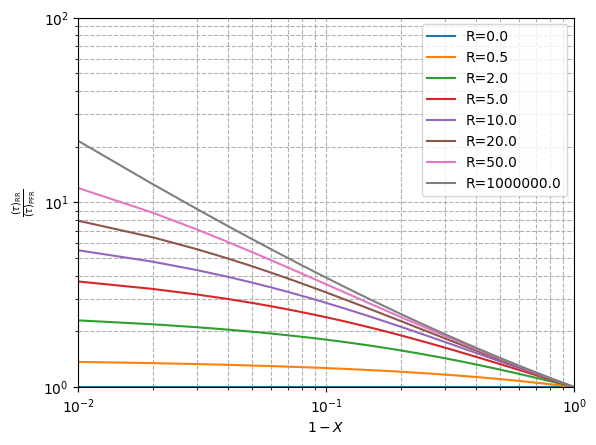

In [113]:
R = np.array([0, 0.5, 2, 5, 10, 20, 50, 1e6])

X = np.linspace(1e-2, 0.99, 100) # rango de conversión
curves = np.empty((len(X), len(R)))

for ii, x in enumerate(X):
    for jj, r in enumerate(R):
        x1 = x
        x0 = r/(r+1)*x1
        num = (r+1) * quad(inv_rA_01, x0, x1, args=(k, c0, n))[0]
        den = quad(inv_rA_01, 0, x1, args=(k, c0, n))[0]
        curves[ii,jj] = num / den

# grafico
fig, ax = plt.subplots()
for jj, r in enumerate(R):
    ax.plot((1-X), curves[:,jj], label=f"R={r}")
ax.set_xlabel(r"$1-X$")
ax.set_xscale('log')
ax.set_xlim(0.01, 1)
ax.set_ylabel(r"$\frac{(\tau)_{\text{RR}}}{(\tau)_{\text{PFR}}}$")
ax.set_yscale('log')
ax.set_ylim(1, 100)
ax.grid(ls='--', which='both')
ax.legend()
plt.show()

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.